# Milestone 3: Complete Router Simulation
This notebook simulates a single router using First-Come, First-Served logic. We will explicitly simulate 4 Random Variables: A, S, D, and L.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# System Parameters from Milestone 2
lam = 2.0  # Arrival rate (2 packets per second)
mu = 3.0   # Service rate (3 packets per second)
N = 100000 # Number of packets to simulate to get good averages

## Step 1: Simulating the Uncertainty (Random Variables A and S)
Network traffic is random. We use Python to generate random time gaps between packets (Variable A), and random processing times for each packet (Variable S).

In [2]:
# Generate 100,000 random gaps and processing times
A = np.random.exponential(1/lam, N)
S = np.random.exponential(1/mu, N)

# Calculate exact time each packet arrives
arrivals = np.cumsum(A)
print(f'Average time between arrivals: {np.mean(A):.4f} seconds')
print(f'Average processing time: {np.mean(S):.4f} seconds')

Average time between arrivals: 0.5011 seconds
Average processing time: 0.3328 seconds


## Step 2: The Deterministic Logic (First-Come, First-Served)
The router has a strict rule: whoever arrives first gets served first. There is no randomness here. We use **Lindley's Recursion** to calculate this step-by-step.

In [3]:
starts = np.zeros(N)
departs = np.zeros(N)

# The first packet doesn't wait
starts[0] = arrivals[0]
departs[0] = starts[0] + S[0]

# For all other 99,999 packets:
for i in range(1, N):
    # You start when you arrive, OR when the packet in front of you leaves.
    starts[i] = max(arrivals[i], departs[i-1])
    departs[i] = starts[i] + S[i]

## Step 3: Calculating Random Variable D (Total Delay)
Delay is simply the time a packet leaves minus the time it arrived.

In [4]:
D = departs - arrivals
print(f'Empirical Average Delay E[D]: {np.mean(D):.4f} seconds')
print(f'Theoretical Average Delay: {1/(mu-lam):.4f} seconds')

Empirical Average Delay E[D]: 0.9809 seconds
Theoretical Average Delay: 1.0000 seconds


## Step 4: Tracking Random Variable L (Queue Length)
To see how many packets are in the router at any given time, we create a timeline of +1 (arrivals) and -1 (departures).

In [10]:
# Step 4: Tracking Random Variable L (Queue Length)
events = [(arrivals[i], 1) for i in range(N)] + [(departs[i], -1) for i in range(N)]
events.sort(key=lambda x: x[0])

current_L = 0
area_L = 0.0
last_time = 0.0

# Create the lists to hold our data for the graph!
time_history = []
L_history = []

for time, change in events:
    dt = time - last_time
    area_L += current_L * dt
    current_L += change
    last_time = time
    
    # Save the first 300 events so we can plot them clearly
    if len(time_history) < 300:
        time_history.append(time)
        L_history.append(current_L)

E_L = area_L / last_time
print(f'Average Packets in System E[L]: {E_L:.4f}')
print(f'Checking Littles Law (L = lambda * D): {E_L:.4f} == {lam * np.mean(D):.4f}')

Average Packets in System E[L]: 1.9575
Checking Littles Law (L = lambda * D): 1.9575 == 1.9617


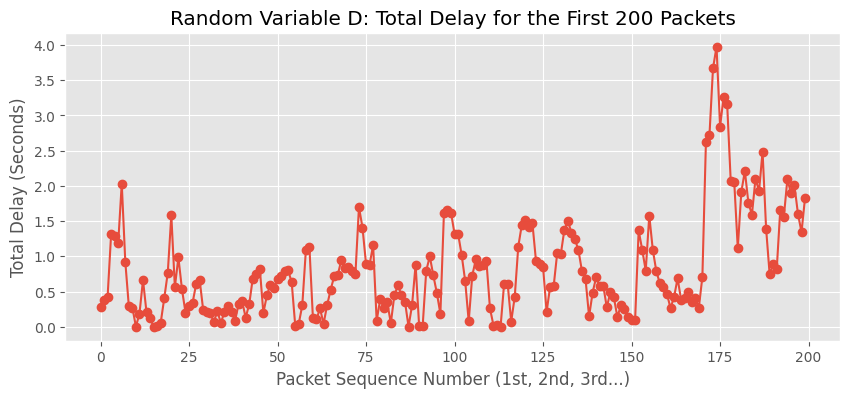

In [9]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# We plot only the first 200 packets so we can clearly see the individual spikes
plt.figure(figsize=(10, 4))
plt.plot(range(200), D[:200], marker='o', color='#e74c3c', linewidth=1.5)

plt.title('Random Variable D: Total Delay for the First 200 Packets')
plt.xlabel('Packet Sequence Number (1st, 2nd, 3rd...)')
plt.ylabel('Total Delay (Seconds)')
plt.show()

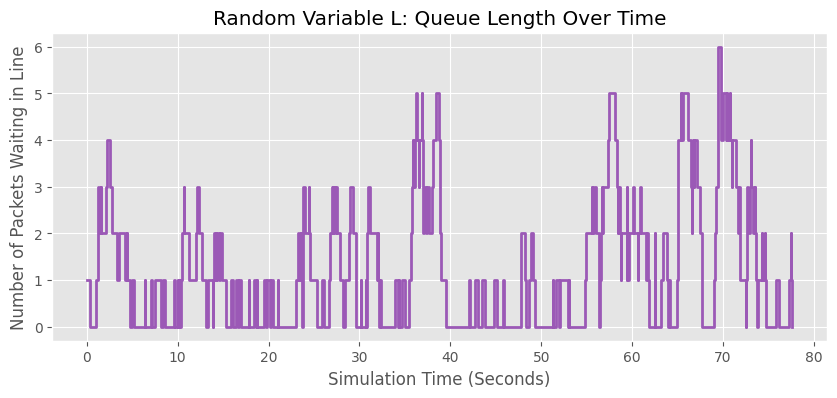

In [11]:
# We use a 'step' plot because packets enter and leave instantly (discrete events)
plt.figure(figsize=(10, 4))
plt.step(time_history, L_history, where='post', color='#9b59b6', linewidth=2)

plt.title('Random Variable L: Queue Length Over Time')
plt.xlabel('Simulation Time (Seconds)')
plt.ylabel('Number of Packets Waiting in Line')
plt.show()